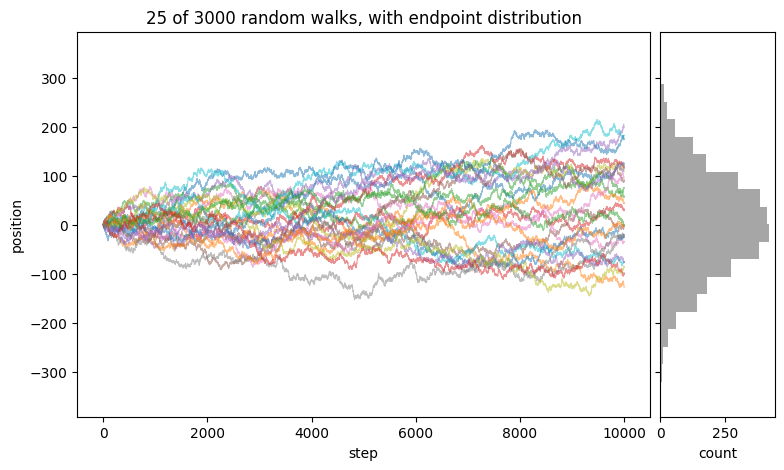

In [16]:
import random
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


def random_walk(steps):
    # store position after each step in a list
    positions = []
    position = 0
    for _ in range(steps):
        step = 1 if random.randint(0, 1) else -1  # +1 or -1 with equal probability
        position += step
        positions.append(position)
    return positions


steps = 10000      # length of each walk (x-axis of the line plot)
n_walks = 3000     # ensemble size — enough endpoints for a smooth distribution
n_shown = 25      # how many trajectories to actually draw (keeps it readable)

# Generate the whole ensemble ONCE so the lines and the histogram describe the
# SAME walks — no mismatch between what's drawn and what's binned.
walks = [random_walk(steps) for _ in range(n_walks)]
final_positions = [w[-1] for w in walks]   # endpoint of each walk; length n_walks

fig, ax = plt.subplots(figsize=(9, 5))

# Draw a readable subset of trajectories. Low alpha so overlapping paths
# don't merge into a solid block.
for w in walks[:n_shown]:
    ax.plot(w, alpha=0.5, linewidth=0.8)

ax.set_xlabel("step")
ax.set_ylabel("position")
ax.set_title(f"{n_shown} of {n_walks} random walks, with endpoint distribution")

# --- the actual fix -------------------------------------------------------
# Put the histogram on its OWN axis to the right, SHARING the y-axis (position)
# with the walks. A horizontal hist on the main axes fails because the bar
# length is a COUNT (~0-40) while the walk x-axis spans 0-1000 steps, so the
# bars collapse into an invisible sliver at x=0 instead of sitting on the right.
divider = make_axes_locatable(ax)
ax_hist = divider.append_axes("right", size="20%", pad=0.1, sharey=ax)

ax_hist.hist(final_positions, bins=20, orientation="horizontal",
             color="gray", alpha=0.7)
ax_hist.set_xlabel("count")
ax_hist.tick_params(axis="y", labelleft=False)  # y labels already shown on the left

plt.show()
